# 01 · Load a Duke OCT volume with eyepy

This notebook loads a single OCT volume from the **Duke SD-OCT** dataset (`data/duke`) using
[`eyepy`](https://github.com/MedVisBonn/eyepy), prints its metadata, and visualizes the central
B-scan and the en-face projection.

**About the data layout.** In this copy of the dataset each subject is stored as a folder of
8-bit TIFF B-scans, e.g. `data/duke/NORMAL1/TIFFs/8bitTIFFs/01.tif … 097.tif`. eyepy reads this
layout with `eyepy.import_bscan_folder`, which stacks the per-B-scan TIFFs into an `EyeVolume`.

> Because the source here is a plain image folder (not a vendor `.vol`/`.e2e`/`.fda` file), there is
> **no embedded acquisition metadata**: voxel spacing defaults to `1 pixel` and no device string is
> stored. The Duke SD-OCT set (Farsiu et al., *Ophthalmology* 2014; Chiu et al. 2015) was acquired on
> **Bioptigen SD-OCT** scanners — we note that from the dataset documentation, not from the files.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import eyepy

print("eyepy version:", eyepy.__version__)


def find_duke_root(start: Path) -> Path:
    """Walk upward from `start` until we find a `data/duke` directory."""
    for base in [start, *start.parents]:
        candidate = base / "data" / "duke"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("Could not locate a 'data/duke' directory above " + str(start))


DUKE_ROOT = find_duke_root(Path.cwd())

# A real volume from the dataset: subject NORMAL1, 97 B-scans of 8-bit TIFFs.
VOLUME_DIR = DUKE_ROOT / "NORMAL1" / "TIFFs" / "8bitTIFFs"
assert VOLUME_DIR.is_dir(), VOLUME_DIR
print("Loading volume from:", VOLUME_DIR)
print("Number of TIFF files on disk:", len(sorted(VOLUME_DIR.glob("*.tif"))))

eyepy version: 0.6.1
Loading volume from: /Users/rahulsmacbook/Desktop/retina-painter/retina-painter/data/duke/NORMAL1/TIFFs/8bitTIFFs
Number of TIFF files on disk: 97


## 1. Load the volume

In [2]:
# import_bscan_folder stacks the per-B-scan TIFFs (natural-sorted) into an EyeVolume.
volume = eyepy.import_bscan_folder(VOLUME_DIR)
volume

## 2. Volume metadata

Number of B-scans, per-B-scan resolution, voxel spacing, and the (lack of) device string.

In [3]:
n_bscans, height, width = volume.shape  # (B-scans, A-scan depth, A-scans/width)
meta = volume.meta

print("=== Duke OCT volume metadata ===")
print(f"Subject / path        : {VOLUME_DIR.relative_to(DUKE_ROOT.parent.parent)}")
print(f"Volume array shape    : {volume.shape}  (n_bscans, height, width)")
print(f"Number of B-scans     : {n_bscans}")
print(f"B-scan resolution     : {height} px (depth) x {width} px (width)")
print(f"Voxel data dtype      : {volume.data.dtype}")
print()
print("--- Voxel spacing (from eyepy) ---")
print(f"scale_z (between B-scans): {meta['scale_z']} {meta['scale_unit']}")
print(f"scale_y (axial / depth)  : {meta['scale_y']} {meta['scale_unit']}")
print(f"scale_x (lateral / width): {meta['scale_x']} {meta['scale_unit']}")
print("(scale defaults to 1 pixel: a TIFF folder carries no physical spacing.)")
print()
print("--- Device ---")
device = dict(meta).get("device")
print(f"Device string in file : {device!r}  (import_bscan_folder stores none)")
print("Known acquisition device (dataset docs): Bioptigen SD-OCT")

=== Duke OCT volume metadata ===
Subject / path        : data/duke/NORMAL1/TIFFs/8bitTIFFs
Volume array shape    : (97, 496, 512)  (n_bscans, height, width)
Number of B-scans     : 97
B-scan resolution     : 496 px (depth) x 512 px (width)
Voxel data dtype      : uint8

--- Voxel spacing (from eyepy) ---
scale_z (between B-scans): 1 pixel
scale_y (axial / depth)  : 1 pixel
scale_x (lateral / width): 1 pixel
(scale defaults to 1 pixel: a TIFF folder carries no physical spacing.)

--- Device ---
Device string in file : None  (import_bscan_folder stores none)
Known acquisition device (dataset docs): Bioptigen SD-OCT


## 3. Central B-scan

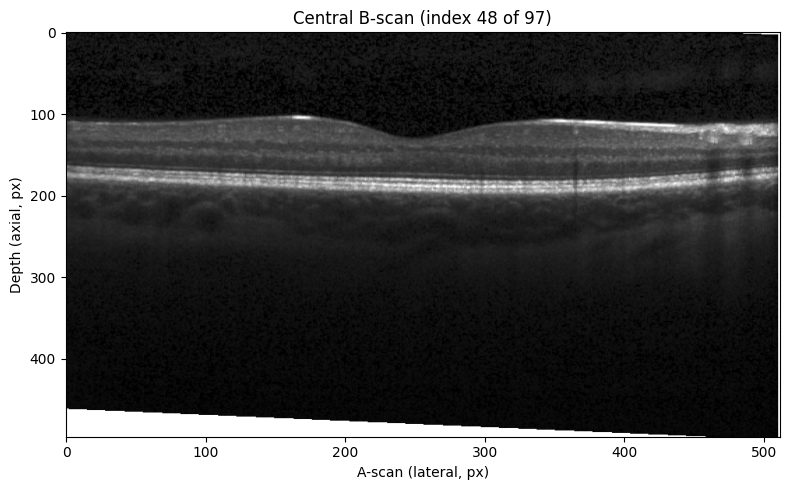

In [4]:
center_idx = n_bscans // 2
center_bscan = volume[center_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(center_bscan.data, cmap="gray", aspect="auto")
ax.set_title(f"Central B-scan (index {center_idx} of {n_bscans})")
ax.set_xlabel("A-scan (lateral, px)")
ax.set_ylabel("Depth (axial, px)")
plt.tight_layout()
plt.show()

## 4. En-face image

This copy of the dataset has no embedded fundus/SLO image, so eyepy provides an en-face
**localizer** that it synthesizes by projecting the OCT volume (a mean-intensity projection along
depth). It is shown below for orientation; it is a derived projection, not a real fundus photo.

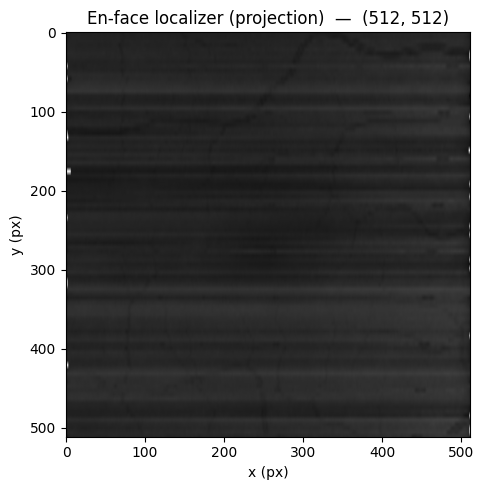

In [5]:
localizer = volume.localizer  # EyeEnface, auto-generated from the volume

if localizer is not None:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(localizer.data, cmap="gray")
    ax.set_title(f"En-face localizer (projection)  —  {localizer.data.shape}")
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    plt.tight_layout()
    plt.show()
else:
    print("No en-face / fundus image available for this volume.")